
# 10 - Group data with clustering algorithms

In this notebook, you will use K-Means clustering to find structure in the classic Iris dataset.


## Load the Iris dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
iris = pd.read_csv("/content/sample_data/iris.csv")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## Prepare numeric features for clustering

In [5]:
X = iris[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Scale the features

In [7]:
import sklearn

scaler = sklearn.preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

## Fit a K-Means clustering model

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(X_scaled)

labels = kmeans.labels_

## Compare clusters to true species labels

In [30]:
iris["cluster"] = labels

crosstab = pd.crosstab(iris["cluster"], iris["species"])
crosstab

species,setosa,versicolor,virginica
cluster,,,
0,0,50,50
1,50,0,0


## Visualize clusters in feature space

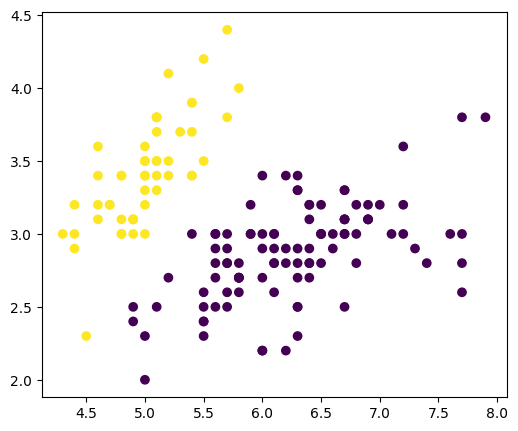

In [31]:
plt.figure(figsize=(6,5))
scatter = plt.scatter(
    iris["sepal_length"],
    iris["sepal_width"],
    c=iris["cluster"]
)

## Choose the number of clusters using hte "Elbow Method"

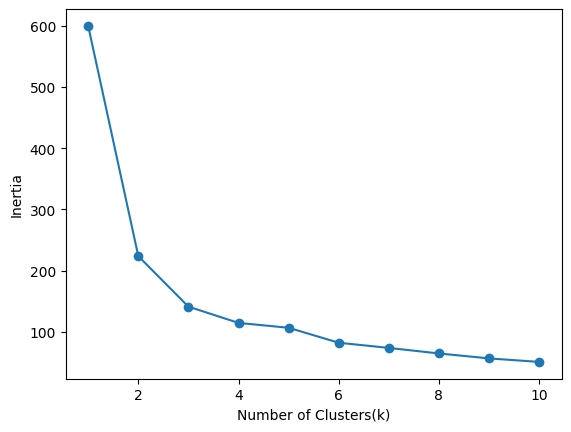

In [33]:
results = []
for k in range(1,11):
  km = KMeans(n_clusters=k)
  km.fit(X_scaled)
  results.append(km.inertia_)

plt.plot(range(1,11), results, marker='o')
plt.xlabel("Number of Clusters(k)")
plt.ylabel("Inertia")
plt.show()